# Post-training Quantization

When neural networks were first being developed, the biggest challenge was getting them to work at all! That meant that accuracy and speed during training were the top priorities. Using **floating-point arithmetic** was the easiest way to preserve accuracy, and GPUs were well-equipped to accelerate those calculations, so it’s natural that not much attention was paid to other numerical formats. 

Neural networks are trained through stochastic gradient descent,  applying many tiny modifications to the weights. These small increments typically need floating-point precision to work, otherwise we can get into the **vanishing gradient** problem. Moreover, the computation demands of training grow with the number of researchers.

The needs for inference are very different. The computation demands of inference grow with the number of users! That means that **inference efficiency** has become a burning issue for a lot of teams in organizations that are deploying ML solutions. That is where **quantization** comes in: store numbers and perform calculations on them in more compact formats than 32-bit floating-point. 

<img src="./images/02.png" width="300">

We're going to take a value that's expressed in float 32-bits (which takes 4 bytes) and compress it down into an integer 8-bits (only 1 byte), so we get a 4x reduction.

First of all, we explore how [**TensorFlow Lite**](https://www.tensorflow.org/lite) works starting from a simple Keras model:

In [4]:
import numpy as np

xs = np.array([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0], dtype=float)
ys = np.array([-3.0, -1.0, 1.0, 3.0, 5.0, 7.0], dtype=float)

In [2]:
import tensorflow  as tf
#tf.get_logger().setLevel(0)
#tf.autograph.set_verbosity(0)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(units=1, input_shape=[1])
])

In [5]:
model.compile(optimizer='sgd', loss='mean_squared_error')
results = model.fit(xs, ys, epochs=500, verbose=0)

tf.saved_model.save(model, "./models/simple")

INFO:tensorflow:Assets written to: ./models/simple/assets


INFO:tensorflow:Assets written to: ./models/simple/assets


The [TFLite Converter](https://www.tensorflow.org/lite/models/convert) can be used in order to generate a [FlatBuffer](https://flatbuffers.dev/) representation (identified by the .tflite file extension), which is an efficient cross-platform serialization format for all major high level languages and performance-critical applications. The main advantage of this format is that it allows access to the serialized data without parsing or unpacking.  

In [6]:
converter = tf.lite.TFLiteConverter.from_saved_model("./models/simple")
tflite_model = converter.convert()

2023-05-28 13:21:42.685028: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2023-05-28 13:21:42.685396: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2023-05-28 13:21:42.686547: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: ./models/simple
2023-05-28 13:21:42.687227: I tensorflow/cc/saved_model/reader.cc:89] Reading meta graph with tags { serve }
2023-05-28 13:21:42.687241: I tensorflow/cc/saved_model/reader.cc:130] Reading SavedModel debug info (if present) from: ./models/simple
2023-05-28 13:21:42.691951: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2023-05-28 13:21:42.720496: I tensorflow/cc/saved_model/loader.cc:215] Running initialization op on SavedModel bundle at path: ./models/simple
2023-05-28 13:21:42.727500: I tensorflow/cc/saved_model/loader.cc:314] SavedModel load for tags { serve }; Status: success: OK. Took 40957 micr

Save the lite model:

In [7]:
with open('./models/simple-model.tflite', 'wb') as f:
  f.write(tflite_model)

The TFlite model is a single file that fully encapsulates the model and its saved weights:

In [8]:
import os
print("TFlite model in MB:", os.path.getsize('./models/simple-model.tflite') / float(2**20))

TFlite model in MB: 0.001041412353515625


when we have a converted model, the [TFlite Interpreter](XXX) can be used to run the model and make inferences. Notice that we need to allocate tensors for input and outout, and prepare data accordingly. In that casae, the input tensor should be an array of floating point values. An important task in running models on embedded systems is to format data to the needs of the model. For example, you might be grabbing frames from a camera that has a particular resolution and encoding, but you need to decode them to another format to be used with  the model. A large part of any engineering for ML systems is performing this conversion.

In [9]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)

interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

to_predict = np.array([[10.0]], dtype=np.float32)
print(to_predict)

interpreter.set_tensor(input_details[0]['index'], to_predict)

interpreter.invoke()

tflite_results = interpreter.get_tensor(output_details[0]['index'])
print(tflite_results)

[[10.]]
[[18.987318]]


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Now that we knows how TFLite works, we can consider a more sophisticated example in order to introduce the possibiliy of making optimizations. Let's consider the [cats vs dogs](https://paperswithcode.com/dataset/cats-vs-dogs) image classification problem. We can downalod the dataset using TFDataset:

In [12]:
import tensorflow_datasets as tfds

split=['train[:80%]', 'train[80%:90%]', 'train[90%:]']
(raw_train, raw_validation, raw_test), metadata = tfds.load('cats_vs_dogs', split=split, 
                                                            with_info=True, as_supervised=True)

When working with lots of real-world image data, corrupted images are a common occurence. Let's filter out badly-encoded images:

The data are ready, and we can see we have like 23,000 samples:

In [13]:
num_examples = metadata.splits['train'].num_examples
num_classes = metadata.features['label'].num_classes
class_names = ['cat', 'dog']
print(num_examples)
print(num_classes)

23262
2


Then we set the training batches and validation batches:

In [14]:
def format_image(image, label):
    image = tf.image.resize(image, (224, 224)) / 255.0
    return  image, label

In [15]:
batch_size = 32

train_batches = raw_train.shuffle(num_examples // 4).map(format_image).batch(batch_size).prefetch(1)
validation_batches = raw_validation.map(format_image).batch(batch_size).prefetch(1)
test_batches = raw_test.map(format_image).batch(1)

In order to keep things fast, we are going to do **transfer learning** instead of training a model from scratch. We download a pre-trained model from [TensorFlow Hub](https://www.tensorflow.org/datasets), a repository with hundreds of ready-to-deploy machine learning models in one place. So, we can create a very simple model exploiting the pre-trained [**MobileNetV2**](https://paperswithcode.com/method/mobilenetv2) model ad feature extractor. After that, we add a dense layer in order to make the calssification.

In [17]:
import tensorflow_hub as hub

model_url ="https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"
image_size = (224, 224)
fv_size = 1280

feature_extractor = hub.KerasLayer(model_url, input_shape = image_size + (3,), 
                                   output_shape = [fv_size], trainable=False)

model = tf.keras.Sequential([feature_extractor,
                             tf.keras.layers.Dense(num_classes, activation='softmax')
                            ])

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 1280)              2257984   
                                                                 
 dense_2 (Dense)             (None, 2)                 2562      
                                                                 
Total params: 2,260,546
Trainable params: 2,562
Non-trainable params: 2,257,984
_________________________________________________________________


In [56]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In this way, instead of taking a few hours over many epochsof training, we can fine tune the training over five epochs.

In [57]:
epochs = 5

results = model.fit(train_batches, epochs=epochs, verbose=0,
                    validation_data=validation_batches)

Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 396 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9
Corrupt JPEG data: 228 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 252 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 396 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 239 extraneous bytes before marker 0xd

In [58]:
print('Training Accuracy: ', results.history['accuracy'][4])
print('Validation Accuracy: ', results.history['val_accuracy'][4])

Training Accuracy:  0.9934443831443787
Validation Accuracy:  0.9879621863365173


We can see that we have accuracy of 99.6% on the training set, and 98.8% on the validation set.

Again, we can now apply the TFLite converter to the model:

In [60]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tf.saved_model.save(model, "./models/float_cat_dog_model.tflite")

INFO:tensorflow:Assets written to: /var/folders/np/rkxq5s9x6lzdnx_24x0j3jx80000gn/T/tmpecw7usl8/assets


INFO:tensorflow:Assets written to: /var/folders/np/rkxq5s9x6lzdnx_24x0j3jx80000gn/T/tmpecw7usl8/assets
2023-05-23 17:32:00.879650: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:362] Ignored output_format.
2023-05-23 17:32:00.879665: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:365] Ignored drop_control_dependency.
2023-05-23 17:32:00.879834: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /var/folders/np/rkxq5s9x6lzdnx_24x0j3jx80000gn/T/tmpecw7usl8
2023-05-23 17:32:00.894698: I tensorflow/cc/saved_model/reader.cc:89] Reading meta graph with tags { serve }
2023-05-23 17:32:00.894714: I tensorflow/cc/saved_model/reader.cc:130] Reading SavedModel debug info (if present) from: /var/folders/np/rkxq5s9x6lzdnx_24x0j3jx80000gn/T/tmpecw7usl8
2023-05-23 17:32:00.953722: I tensorflow/cc/saved_model/loader.cc:229] Restoring SavedModel bundle.
2023-05-23 17:32:01.358146: I tensorflow/cc/saved_model/loader.cc:213] Running initialization

In [61]:
import os
print("TFlite model in MB:", os.path.getsize('./models/float_cat_dog_model.tflite') / float(2**20))

TFlite model in MB: 8.46414566040039


Notice that the file is 8.5 MB, which is good for a mobile device, but too big for an embedded system.

We can look also at the performance of the model on the validation set, in order to compare after the optimization. We grab 100 sample images and we make predictions using the interpreter:

In [62]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_index = interpreter.get_input_details()[0]["index"]
output_index = interpreter.get_output_details()[0]["index"]

INFO: Applying 1 TensorFlow Lite delegate(s) lazily.


In [63]:
from tqdm import tqdm
predictions = []

test_labels, test_imgs = [], []
for img, label in tqdm(test_batches.take(200)):
    interpreter.set_tensor(input_index, img)
    interpreter.invoke()
    predictions.append(interpreter.get_tensor(output_index))
    test_labels.append(label.numpy()[0])
    test_imgs.append(img)

100%|██████████| 200/200 [00:13<00:00, 14.47it/s]


In [64]:
score = 0
for item in range(0,len(predictions)):
    prediction = np.argmax(predictions[item])
    label = test_labels[item]
    if prediction == label:
        score = score+1

print("Out of 200 predictions we got " + str(score) + " correct")

Out of 200 predictions we got 200 correct


We can visualize some pictures from the dataset along with the predictions:

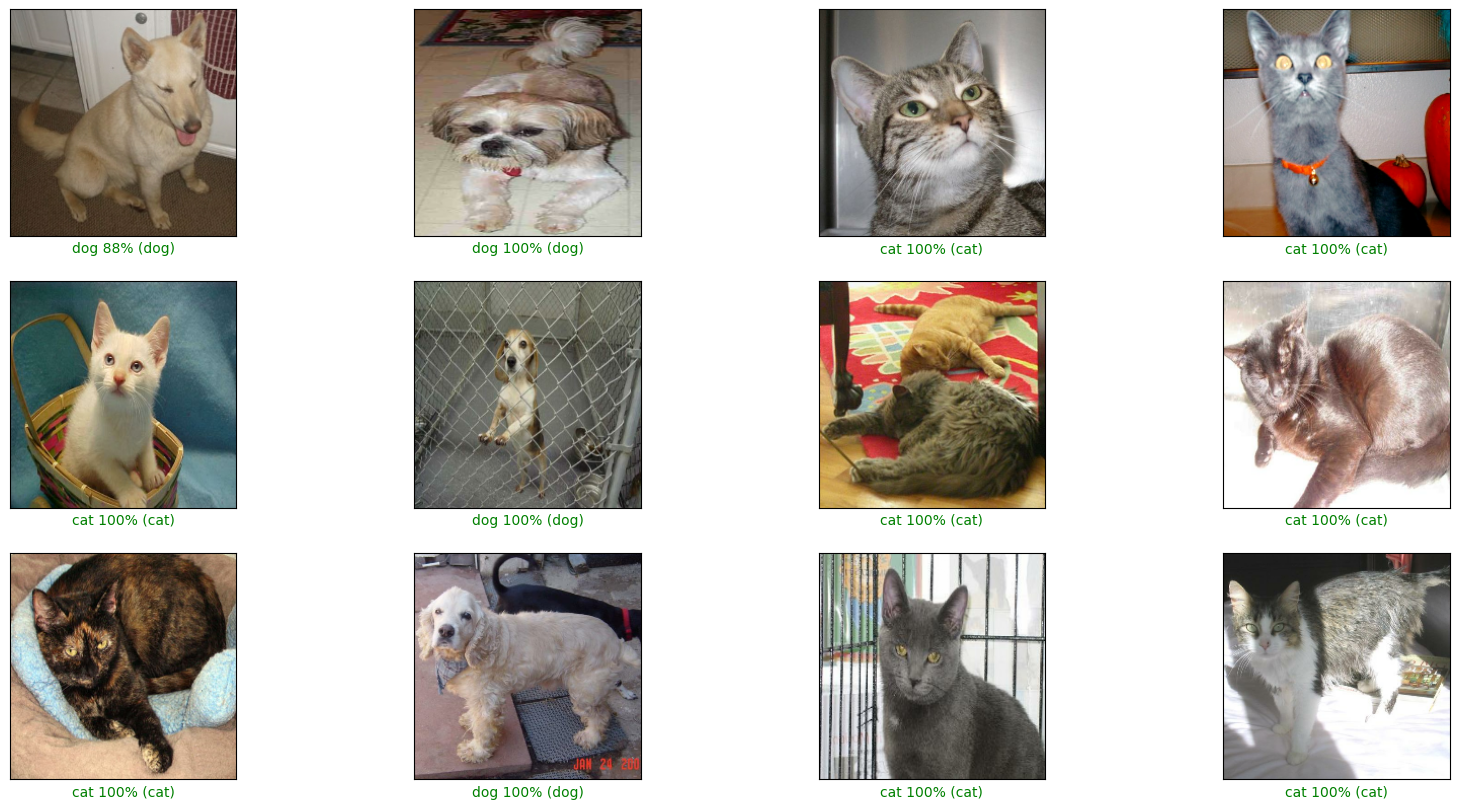

In [65]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20, 10))
rows = 3
columns = 4
for index in range(1, 13):

    img = np.squeeze(test_imgs[index])
    
    fig.add_subplot(rows, columns, index)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions[index])
    if predicted_label == test_labels[index]:
        color = 'green'
    else:
        color = 'red'
    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                         100 * np.max(predictions[index]),
                                         class_names[test_labels[index]]), color=color)

Now, we can introduce quantization to the converted model in order to optimize it to run on smaller systems. In a neural network, we have neurons that have weights and biases, and we have activations that are going out the neuron. We can perform quantizations at various different levels:

<img src="./images/05.png" width="500">

The first one is doing quantization with weights, because they play a major role in terms of storage. We can observer, from experimentation, that the weight values tend to be very concentrated around certain critical ranges. For example, the following figure shows the network distribution weights for AlexNet:

<img src="./images/03.png" width="400">

Thanks to this observation, we can actually quantize weights without losing the general representation of that space. If you look at the graph on the left, and you look at the graph on the right, you discretizing the data, but we can still see the same trend:

<img src="./images/06.png" width="600">

We are binning the original floating point values into an 8-bit encoding scheme, so we have 2^8 (256) potential values:

<img src="./images/07.png" width="700">

Now the network is actually 8 bits and we can save it in order to shrunk the model size down by 4x. Then when we start running it to do the inference, we take the 8-bit values and reconstruct them into a 32-bit floating point value. 

<img src="./images/08.png" width="700">

Notice that we can have some side effects. Certain values that are inside the original range will get bucketed into some bit encoding (for example, -5.4 gets bucketed into 0) which later we decompress into the negative -5.4 value, because 0 happens to map for that. However, sometimes we can have a situation where two floating point values are close to each other and they fall into the same integer bucket, and when we decompress the value,
it comes into the same floating point value, and we lost some resolution that we previously have in the original. This is a trade-off we should take into account. 

<img src="./images/09.png" width="700">

This is the first step of the quantization scheme (**quantized weight compression**) and it is done for size reduction and we assume to have floating point arithmetic capability. 
For every time we get the quantized value, we convert it by scaling the range back into its original. Mathematically, a floating point value $x \in [min, max]$ is quantized to a b-bit integer (tipically 8-bit signed or unsigned)  $x_q \in [min_q, max_q]$:

$\begin{align}
x_q = \text{round}(\frac{x}{s} + z)
\end{align}$

The de-quantization process is defined as:

$\begin{align}
x = s(x_q - z)
\end{align}$

where **$s$ (scale)** and **$z$ (zero point)** are parameters which can be derived in order to assure that $min_q$ maps to $min$ and $max_q$ maps to $max$. 

So we would just have to solve a linear system:

$\begin{align}
min = s(min_q - z)
\end{align}$

$\begin{align}
max = s(max_q - z)
\end{align}$

The solution is:

$\begin{align}
s = \frac{max - min}{max_q - min_q}
\end{align}$

$\begin{align}
z = \frac{min \cdot max_q - max \cdot min_q}{min - max}
\end{align}$

In practice, we can have chance to have $x$ that is outside the range of $[min, max]$, thus the quantized value $x_q$  will also be outside the range of $[min_q, \max_q]$ and we need to clip the values that are outside the range. More concretely, the quantization process will have an additional clip step: 

$\begin{align}
x_q = \text{clip}(\text{round}(\frac{x}{s} + z), min_q, max_q)
\end{align}$

If the integer type is **signed INTb** then:

$\begin{align}
(min_q, max_q) = (-2^{b-1}, 2^{b-1}-1)
\end{align}$

else, if the integer type is **unsigned UINTb** then:

$\begin{align}
(min_q, max_q) = (0, 2^b-1)
\end{align}$

Let's try to write it in Python:

In [200]:
import numpy as np

def quantization(x, s, z, qmin, qmax):
    qx = np.round(1 / s * x + z, decimals=0)
    qx = np.clip(qx, a_min=qmin, a_max=qmax)
    return qx

def dequantization(qx, s, z):
    x = s * (qx - z)
    return x

def generate_quantization_constants(min, max, bits=8, unsigned=0):
    qmin = -np.power(2, bits-1)
    if unsigned:
        qmin = 0  
    qmax = np.power(2, bits-1) - 1
    if unsigned:
        qmax = np.power(2, bits)
    s = (max - min) / (qmax - qmin)
    z = int((max * qmin - min * qmax) / (max - min))
    return s, z, qmin, qmax

Suppose to have floating point values ranging from -6 to 5 and an 8 bit signed conversion (-128, 127):

In [205]:
min = -6
max = 5
bits = 8

s, z, qmin, qmax = generate_quantization_constants(min=min, max=max, bits=bits, unsigned=0)

print("s = ", s)
print("z = ", z)
print("qmin = ", qmin)
print("qmax = ", qmax)

s =  0.043137254901960784
z =  11
qmin =  -128
qmax =  127


In [206]:
x = -5.4
qx = quantization(x, s, z, qmin, qmax)
nx = dequantization(qx, s, z)

print("x = ", x)
print("qx = ", qx)
print("nx = ", nx)

x =  -5.4
qx =  -114.0
nx =  -5.3921568627450975


In [212]:
min = -6
max = 5
bits = 4

s, z, qmin, qmax = generate_quantization_constants(min=min, max=max, bits=bits, unsigned=0)
x = np.arange (min-1, max+1, 0.1)
qx = quantization(x, s, z, qmin, qmax)

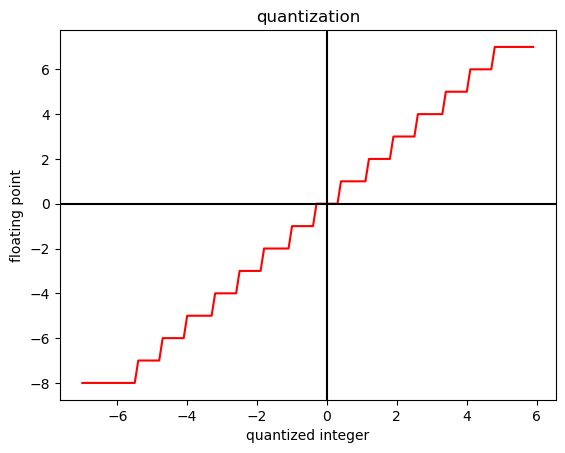

In [213]:
import matplotlib.pyplot as plt

plt.plot(x, qx, 'r')
plt.title('quantization')
plt.ylabel('floating point')
plt.xlabel('quantized integer')
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.show()

We can calulcate the error betwee the orginal value and the reconstructed one: 

In [214]:
x = np.arange (min, max, 0.1)
qx = quantization(x, s, z, qmin, qmax)
nx = dequantization(qx, s, z)

errors = nx - x
max_error = np.max(errors)

print("Max Error  : ", max_error)

Max Error  :  0.33333333333337123


In the end, once the dequantization function finishes, we have a floating-point value back from the stored integer value, and then we can perform floating-point operations like in a standard neural network. The benefit is that the size of the model is smaller and in general if our scale is smaller, it is more likely to have smaller errors.

However, we can be interested also in speed up the inference in order to optimize latency (**quantized inference calculation**), in that case, we  need to get rid of operations with integer arithmetic and we need to quantize also input and bias. 

Suppose we have to perform the tipycal matrix operatoin of a layer of neurons with $p$ features, $m$ samples and $n$ neurons:

$\begin{align}
Y = X W + b
\end{align}$

where 
- $X \in R^{m \times p}$ represents the matrix of input features, it has one row per instance and one column per feature
- $W \in R^{p \times n}$ is the weight matrix, it has one row per feature and one column per neuron
- $b \in R^n$ is the bias vector, it has one term per neuron
- $Y \in R^{m \times n}$ is the activations matrix, it has one row per instance and one column per neuron

The output value for the neuron $j$ for the input sample $i$ is

$\begin{align}
Y_{i,j} = b_j + \sum\limits_{k=1}^{p}{X_{i,k}W_{k,j}} 
\end{align}$

we would need to do $p$ floating number multiplications and $p$ floating number additions to compute this single entry of $Y$. To complete the full matrix multiplication, given there are ($m \cdot n$) entries in $Y$, we would need to do ($m\cdot p\cdot n$) floating number multiplications and ($m\cdot p\cdot n$) floating number additions.

We can execute the matrix multiplication using quantized values:

$\begin{align}
= s_b(b_{q,j}-z_b) + \sum\limits_{k=1}^{p}{s_X(X_{q,i,k}-z_X)s_W(W_{q,k,j}-z_W)}=
\end{align}$

$\begin{align}
= s_b(b_{q,j}-z_b) + s_X s_W \sum\limits_{k=1}^{p}{(X_{q,i,k}-z_X)(W_{q,k,j}-z_W)}=
\end{align}$

$\begin{align}
= s_b(b_{q,j}-z_b) + s_X s_W \left[ (\sum\limits_{k=1}^{p}{X_{q,i,k}W_{q,k,j}}) - (z_W \sum\limits_{k=1}^{p}{X_{q,i,k}}) - (z_X \sum\limits_{k=1}^{p}{W_{q,i,k}}) + p z_X z_W \right]
\end{align}$

where 
- $X_q$, $W_q$ and $b_q$ are the quantized matrix for $X$, $W$ and $b$
- $s_X$, $s_W$ and $s_b$ are the scales
- $z_X$, $z_W$ and $z_b$ are the zero pointsa

We can now express the operation with quantized matrix $Y_q$:

$\begin{align}
Y_{i,j} = s_Y(Y_{q,i,j}-z_Y)
\end{align}$

therefore,

$\begin{align}
Y_{q,i,j} = z_Y + \frac{s_b}{s_Y}(b_{q,j}-z_b) + \frac{s_X s_W}{s_Y} \left[ (\sum\limits_{k=1}^{p}{X_{q,i,k}W_{q,k,j}}) - (z_W \sum\limits_{k=1}^{p}{X_{q,i,k}}) - (z_X \sum\limits_{k=1}^{p}{W_{q,i,k}}) + p z_X z_W \right]
\end{align}$

Notice that several terms are constant during the inference (don't depend on the particular input) and can be computed offline:

$\begin{align}
- z_Y
\end{align}$

$\begin{align}
- \frac{s_b}{s_Y}(b_{q,j}-z_b)
\end{align}$

$\begin{align}
- z_X \sum\limits_{k=1}^{p}{W_{q,i,k}}
\end{align}$

$\begin{align}
- p z_X z_W
\end{align}$

The term

$\begin{align}
\sum\limits_{k=1}^{p}{X_{q,i,k}W_{q,k,j}}
\end{align}$

suggest that we could do the integer matrix multiplication for $X_q$ and $W_q$. 

The floating-point arithmetic implemented in any silicon is often slower than integer arithmetic (a cycle or two versus ten or more cycles). It is almost an order of magnitude different in terms of the computational performance requirement. So reducing a model from using floating-point values and operations to integer values and operationa (that are easier to physically compute in silicon) actually gives us a massive improvement in performance. The following figure shows an example of three different models that are operating in either floating point or integer:

<img src="./images/04.png" width="600">

Moreover, such integer matrix multiplication could employ special hardware and algorithms, such as [NVIDIA Tensor Core IMMA operations](https://docs.nvidia.com/cuda/ampere-tuning-guide/index.html#tensor-operations) that runs much faster than conventional integer matrix multiplication.

In a DNN we have more than one layer:

$\begin{align}
X_1 = X_0W_0 + b_0
\end{align}$

$\begin{align}
X_2 = X_1W_1 + b_1
\end{align}$

$\begin{align}
...
\end{align}$

$\begin{align}
X_n = X_{n-1}W_{n-1} + b_{n-1}
\end{align}$

if $Q$ is the quantization function, $MQ$ is the quantized matrix multiplication previously defined and and $D$ is the de-quantization function, se can convert all steps quatized matrices:

$\begin{align}
X_{0,q} = Q(X_0, s_{X_0}, z_{X_0})
\end{align}$

$\begin{align}
X_{1,q} = MQ(X_{0,q}, W_{0,q}, b_{0,q})
\end{align}$

$\begin{align}
X_{2,q} = MQ(X_{1,q}, W_{1,q}, b_{1,q})
\end{align}$

$\begin{align}
...
\end{align}$

$\begin{align}
X_{n,q} = MQ(X_{n-1,q}, W_{n-1,q}, b_{n-1,q})
\end{align}$

$\begin{align}
X_n = D(X_{n,q}, s_{X_n}, z_{X_n})
\end{align}$

In the following, we implement the quantization matrix multiplication in Python:

In [252]:
def quantization_matrix_multiplication(qX, qW, qb, sx, zx, sw, zw, sb, zb, sy, zy):
    p = qW.shape[0]
    qY = (zy + 
          (sb / sy * (qb - zb)).astype(np.int8) +
          ((sx * sw / sy) * (np.matmul(qX, qW) - 
                               zw * np.sum(qX, axis=1, keepdims=True) -
                               zx * np.sum(qW, axis=0, keepdims=True) +
                               p * zx * zw)).astype(np.int8)).astype(np.int8)

    return qY

We can make an example comparing the floating point multiplication and the quantized multiplication for some random matices:

In [256]:
m = 2 #inputs
p = 3 #features
n = 4 #neurons
bits = 8

# X
Xmin = -100.0
Xmax = 80.0
X = np.random.uniform(low=Xmin, high=Xmax, size=(m,p)).astype(np.float32)
sx, zx, qminx, qmaxx = generate_quantization_constants(Xmin, Xmax, bits)
qX = quantization(X, sx, zx, qminx, qmaxx)

# W
Wmin = -20.0
Wmax = 10.0
W = np.random.uniform(low=Wmin, high=Wmax, size=(p,n)).astype(np.float32)
sw, zw, qminw, qmaxw = generate_quantization_constants(Wmin, Wmax, bits)
qW = quantization(W, sw, zw, qminw, qmaxw)

# b
bmin = -500.0
bmax = 500.0
sb, zb, qminb, qmaxb  = generate_quantization_constants(bmin, bmax, bits)
b = np.random.uniform(low=bmin, high=bmax, size=(1,n)).astype(np.float32)
qb = quantization(b, sb, zb, qminb, qmaxb)

# Y
Y = np.matmul(X, W) + b

# Quantized Matrix Multiplication 
Ymin = -3000.0
Ymax = 3000.0
sy, zy, qminy, qmaxy = generate_quantization_constants(Ymin, Ymax, bits)
qY = quantization_matrix_multiplication(qX, qW, qb, sx, zx, sw, zw, sb, zb, sy, zy)

nY = dequantization(qY, sy, zy)

print("Y:")
print(Y)
print("Quantized Y from matrix multiplication:")
print(qY)
print("Dequantized Y:")
print(nY)

Y:
[[ 1717.9231  -1086.117    1074.5242    586.24414]
 [-1295.1864    241.29681  -742.6207   -937.17413]]
Quantized Y from matrix multiplication:
[[ 72 -45  45  25]
 [-54  10 -31 -39]]
Dequantized Y:
[[ 1694.11764706 -1058.82352941  1058.82352941   588.23529412]
 [-1270.58823529   235.29411765  -729.41176471  -917.64705882]]


In [257]:
qY_expected = quantization(Y, sy, zy, qminy, qmaxy)

print("Expected qY:")
print(qY_expected)

Expected qY:
[[ 73. -46.  46.  25.]
 [-55.  10. -32. -40.]]


Notice that the product FP32 matrix computed using quantized matrices is close to the expectation computed using matrices floating point matrices.

In addition to matrix multiplications, deep learning models also have non-linear activation layers such as ReLU. So the question becomes how do we deal with these layers in a quantized deep learning model in practice?

One trivial solution is to de-quantize the quantized input tensor to these layers, use ordinary floating point computations, and quantize the output tensors. This will work if there are only a few such layers in the model or there is no special implementations to handle these layers in a quantized manner. However, in most of the deep learning models, the number of such layers are not negligible, and using this trivial solution is likely to slow the inference down significantly.

The other solution is to deal with each individual special layers carefully. As an example, we can consider the quantized version of the ReLU activation function:

We define the activation function ReLU as follows. This might look different from the the conventional ReLU definition, but such definition is more generalized and is convenient for the demonstration of quantized ReLU.

$\begin{align}
\text{ReLU}(x,x_t,y_v,k)= \Big\{ \begin{matrix} y_v  \enspace \enspace \enspace \enspace \enspace \enspace \enspace \enspace \enspace \enspace \text{if} \enspace x \lt x_t \\ y_v + k(x-x_t) \enspace \text{if} \enspace x\geq x_t \end{matrix} 
\end{align}$

The common ReLU is a special case where $x_t=0$, $y_v=0$ and $k=1$

$\begin{align}
\text{ReLU}(x,0,0,1)= \Big\{ \begin{matrix} 0 \enspace \text{if} \enspace x \lt 0 \\ x \enspace \text{if} \enspace x\geq 0 \end{matrix}
\end{align}$

In [259]:
def relu(x, x_t, y_v, k):
    x = np.clip(x, a_min=x_t, a_max=None)
    y = y_v + k * (x - x_t)
    return y

In [263]:
x_t = 0
y_v = 0
k = 1

x = np.arange (-5, 5, 0.1)
y = relu(x, x_t, y_v, k)

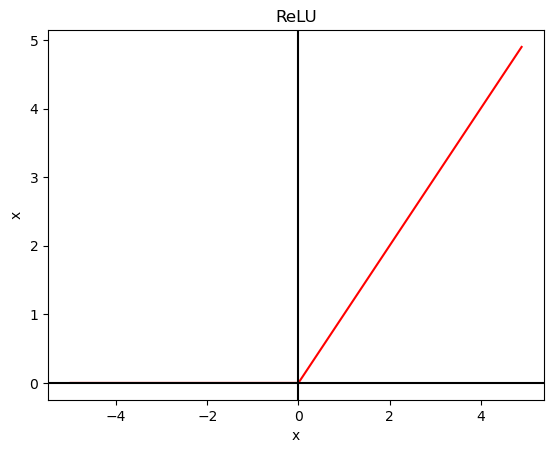

In [264]:
plt.plot(x, y, 'r')
plt.title('ReLU')
plt.ylabel('x')
plt.xlabel('x')
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.show()

Then let’s derive how the quantized ReLU mathematically:

$\begin{align}
y = s_y(y_q - z_y) = \text{ReLU}(s_x(x_q-z_x),0,0,1)= \Big\{ \begin{matrix} 0 \enspace \enspace \enspace \enspace \enspace \enspace \enspace \enspace \text{if} \enspace s_x(x_q-z_x) \lt 0 \\ s_x(x_q-z_x) \enspace \text{if} \enspace s_x(x_q-z_x)\geq 0 \end{matrix} =
\end{align}$

$\begin{align}
= \Big\{ \begin{matrix} 0 \enspace \enspace \enspace \enspace \enspace \enspace \enspace \enspace \text{if} \enspace x_q \lt z_x \\ s_x(x_q-z_x) \enspace \text{if} \enspace x_q \geq z_x \end{matrix}
\end{align}$

therefore,

$\begin{align}
y_q = \Big\{ \begin{matrix} z_y \enspace \enspace \enspace \enspace \enspace \enspace \enspace \enspace \enspace \enspace \text{if} \enspace x_q \lt z_x \\ z_y + \frac{s_x}{s_y} (x_q-z_x) \enspace \text{if} \enspace x_q \geq z_x \end{matrix} = \text{ReLU}(x_q, z_x, z_y, {s_x}/{s_y})
\end{align}$

So it becomes apparent that to do the quantized ReLU corresponding to the floating point $y = ReLU(x,0,0,1)$, we just have to do $y_q = ReLU(x_q, z_x, z_y,  {s_x}/{s_y})$

In [267]:
def quantized_relu(qx, sx, zx, sy, zy):
    qy = relu(qx, zx, zy, sx/sy).astype(np.uint8)
    return qy

In [274]:
Xmax = -60.0
Xmin = 60.0
bits = 8
sx, zx, qminx, qmaxx  = generate_quantization_constants(Xmax, Xmin, bits)

X = np.arange (-5, 5, 0.1)
qX = quantization(X, sx, zx, qminx, qmaxx)

Ymin = -100.0
Ymax = 100.0
sy, zy, qminy, qmaxy = generate_quantization_constants(Ymax, Ymin, bits)

qY = quantized_relu(qX, sx, zx, sy, zy)
Y = dequantization(qY, sy, zy)

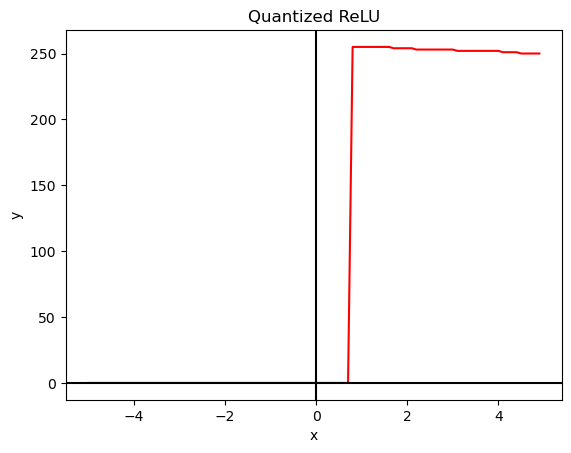

In [275]:
plt.plot(X, qY, 'r')
plt.title('Quantized ReLU')
plt.ylabel('y')
plt.xlabel('x')
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.show()

Another benefit that we get by doing this translation is that we can cut down the power consumption. It is a similar reason as the silicon aspect: floating point arithmetic is also more power hungry.

A final benefit of quantization is portability, which is crucial in embedded systems. These systems often make very aggressive trade-offs and in some cases an embedded silicon might support floating point arithmetic, but another might not support it. Instead the integer arithmetic is a common baseline that is actually available across all of the different systems.

We can set up the **post-training quantization** on the TF Converter by setting the  optimizations property in order to convert and quantize an already-trained TensorFlow model. The converter provides [few options](https://www.tensorflow.org/api_docs/python/tf/lite/Optimize) for what we can do with optimization: **OPTIMIZE_FOR_SIZE** performs optimizations to make the model as small as possible, **OPTIMIZE_FOR_LATENCY** will perform optimizations that reduce inference time as much as possible, **DEFAULT** try to optimize for both. In general, models can be made up to about **four times smaller** with a **two to three time speed-up**.

In [66]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT] 
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: /var/folders/np/rkxq5s9x6lzdnx_24x0j3jx80000gn/T/tmplfge3p08/assets


INFO:tensorflow:Assets written to: /var/folders/np/rkxq5s9x6lzdnx_24x0j3jx80000gn/T/tmplfge3p08/assets
2023-05-23 17:34:42.659221: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:362] Ignored output_format.
2023-05-23 17:34:42.659235: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:365] Ignored drop_control_dependency.
2023-05-23 17:34:42.659414: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /var/folders/np/rkxq5s9x6lzdnx_24x0j3jx80000gn/T/tmplfge3p08
2023-05-23 17:34:42.671252: I tensorflow/cc/saved_model/reader.cc:89] Reading meta graph with tags { serve }
2023-05-23 17:34:42.671263: I tensorflow/cc/saved_model/reader.cc:130] Reading SavedModel debug info (if present) from: /var/folders/np/rkxq5s9x6lzdnx_24x0j3jx80000gn/T/tmplfge3p08
2023-05-23 17:34:42.726945: I tensorflow/cc/saved_model/loader.cc:229] Restoring SavedModel bundle.
2023-05-23 17:34:43.103124: I tensorflow/cc/saved_model/loader.cc:213] Running initialization

In [67]:
_, tflite_file = tempfile.mkstemp('.tflite')

with open(tflite_file, 'wb') as f:
    f.write(tflite_model)

print("TFlite optivized model in MB:", os.path.getsize(tflite_file) / float(2**20))

TFlite optivized model in MB: 2.3935012817382812


Without any optimizations we got 8.5 MB, with the the optimization property set we got 2.4 MB. Depending on the model type, there can be a loss in accuracy, so be sure to test thoroughly to see if the losses are acceptable. We can use the Interpreter to check the accuracy:

In [68]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_index = interpreter.get_input_details()[0]["index"]
output_index = interpreter.get_output_details()[0]["index"]

INFO: Applying 1 TensorFlow Lite delegate(s) lazily.


In [69]:
score = 0

test_labels, test_imgs = [], []
for img, label in tqdm(test_batches.take(200)):
    interpreter.set_tensor(input_index, img)
    interpreter.invoke()
    predictions = interpreter.get_tensor(output_index)
    prediction = np.argmax(predictions)
    if prediction == label:
        score = score+1
        
print("Out of 200 predictions we got " + str(score) + " correct")

100%|██████████| 200/200 [02:51<00:00,  1.16it/s]

Out of 200 predictions we got 200 correct


In that case the drop on performace is not evident. The reasond for this is that trained models tend to cope very well with high levels of noise in their inputs.  If you think about recognizing an object in a photo you’ve just taken, the network has to ignore all the CCD noise, lighting changes, and other non-essential differences between it and the training examples it’s seen before, and focus on the important similarities instead. This ability means that they seem to treat low-precision calculations as **just another source of noise**, and still produce accurate results even with numerical formats that hold less information. We can visualize some pictures from the dataset along with the predictions:

Notice that scale and zero point for weights and bias can be calculated before the inference, becouse their ranges are already available. But how we can calculate scale and zero point for activations? Previosly we used the **dynamic quantization**, in which scale and zero point for activation are calculated on-the-fly (online during inference) and are specific for each forward pass. This means that the activations are always stored in float 32 and they are converted to integers while processing and back to floating point after the processing is done. We can also use **static quantization** to pre-computes scales and zero points also for all the activations in order to eliminate this overhead. However, we need some representative data in order to collect the distribution statistics for all the activation layers and compute an estime of scales and zero points. The short-coming is that if the data is not representative, the scales and zero points computed might not reflect the true scenario during inference, and the inference accuracy will be harmed.

In [70]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT] 

def representative_data_gen():
    for input_value, _ in test_batches.take(100):
        yield [input_value]

        
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

tflite_model = converter.convert()

INFO:tensorflow:Assets written to: /var/folders/np/rkxq5s9x6lzdnx_24x0j3jx80000gn/T/tmpbo0smw4e/assets


INFO:tensorflow:Assets written to: /var/folders/np/rkxq5s9x6lzdnx_24x0j3jx80000gn/T/tmpbo0smw4e/assets
/Users/riccardo.berta/anaconda3/envs/machine-learning/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:765: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "
2023-05-23 17:48:03.946953: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:362] Ignored output_format.
2023-05-23 17:48:03.946968: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:365] Ignored drop_control_dependency.
2023-05-23 17:48:03.947101: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /var/folders/np/rkxq5s9x6lzdnx_24x0j3jx80000gn/T/tmpbo0smw4e
2023-05-23 17:48:03.959936: I tensorflow/cc/saved_model/reader.cc:89] Reading meta graph with tags { serve }
2023-05-23 17:48:03.959950: I tensorflow/cc/saved_model/reader.cc:130] Reading S

We create a function that returns input values, this is called **Data Generator** and we tell the converter to use that as the representative data set for the model. Moreover, we tell the model that the supported operations  should be INT8 by setting relative parameter. Notice that this API is constantly evolving and interface might change, but the underlying concept should remain the same.

In [71]:
import tempfile

_, tflite_file = tempfile.mkstemp('.tflite')

with open(tflite_file, 'wb') as f:
    f.write(tflite_model)

print("TFlite optimized with data generator model in MB:", os.path.getsize(tflite_file) / float(2**20))

TFlite optimized with data generator model in MB: 2.5873641967773438


The following decision tree can help determine which post-training quantization method is best for your use case:

<img src="./images/01.png" width="800">

We make another example with a computer vision model that recognizes [hand gestures for the rock, paper, scissors game](https://www.kaggle.com/datasets/drgfreeman/rockpaperscissors). First of all we get the dataset using TFDS:

In [215]:
split = ['train[:80%]', 'train[80%:]', 'test']
(raw_train, raw_validation, raw_test), metadata = tfds.load('rock_paper_scissors', split=split, 
                                                            with_info=True, as_supervised=True)
num_examples = metadata.splits['train'].num_examples
num_classes = metadata.features['label'].num_classes

In [216]:
print(num_examples)
print(num_classes)

2520
3


In [217]:
batch_size = 32

train_batches = raw_train.shuffle(num_examples // 4).map(format_image).batch(batch_size).prefetch(1)
validation_batches = raw_validation.map(format_image).batch(batch_size).prefetch(1)
test_batches = raw_test.map(format_image).batch(1)

Build and train a baseline model:

In [218]:
model_url ="https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"
image_size = (224, 224)
fv_size = 1280

feature_extractor = hub.KerasLayer(model_url, input_shape = image_size + (3,), 
                                   output_shape = [fv_size], trainable=False)

model = tf.keras.Sequential([feature_extractor,
                             tf.keras.layers.Dense(num_classes, activation='softmax')
                            ])


In [219]:
model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_4 (KerasLayer)  (None, 1280)              2257984   
                                                                 
 dense_7 (Dense)             (None, 3)                 3843      
                                                                 
Total params: 2,261,827
Trainable params: 3,843
Non-trainable params: 2,257,984
_________________________________________________________________


In [220]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [221]:
results = model.fit(train_batches, epochs=5,
                    validation_data=validation_batches, verbose=0)

In [ ]:
print('Training Accuracy: ', results.history['accuracy'][4])
print('Validation Accuracy: ', results.history['val_accuracy'][4])

In [ ]:
plt.plot(results.history['accuracy'], 'g', label='Training Accuracy')
plt.plot(results.history['val_accuracy'], 'b', label='Validation Accuracy')
plt.title('training and validation')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

Convert the model to TFLite:

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

In [ ]:
_, tflite_file = tempfile.mkstemp('.tflite')

with open(tflite_file, 'wb') as f:
    f.write(tflite_model)

print("TFlite model in MB:", os.path.getsize(tflite_file) / float(2**20))

Test the model using an Interpreter to run the model:

In [ ]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_index = interpreter.get_input_details()[0]["index"]
output_index = interpreter.get_output_details()[0]["index"]

In [ ]:
from tqdm import tqdm
predictions = []

test_labels, test_imgs = [], []
for img, label in tqdm(test_batches.take(100)):
    interpreter.set_tensor(input_index, img)
    interpreter.invoke()
    predictions.append(interpreter.get_tensor(output_index))
    test_labels.append(label.numpy()[0])
    test_imgs.append(img)

In [ ]:
score = 0
for item in range(0,len(predictions)):
    prediction = np.argmax(predictions[item])
    label = test_labels[item]
    if prediction == label:
        score = score+1

print("Out of 100 predictions we got " + str(score) + " correct")

Plot the results

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20, 10))
rows = 3
columns = 4
for index in range(1, 13):

    img = np.squeeze(test_imgs[index])
    
    fig.add_subplot(rows, columns, index)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions[index])
    if predicted_label == test_labels[index]:
        color = 'green'
    else:
        color = 'red'
    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                         100 * np.max(predictions[index]),
                                         class_names[test_labels[index]]), color=color)